In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d
import scipy
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
from collections import OrderedDict
import pyslha
import ROOT
import xml.etree.ElementTree as ET
import pylhe

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution

Welcome to JupyROOT 6.26/10


In [2]:
def readNumEvents(file):
    """
    Moderately efficent way to get the number of events stored in file.
    """
    
    with pylhe._extract_fileobj(file) as fileobj:
        nevts = sum(element.tag == "event" for event, element in ET.iterparse(fileobj, events=["end"]))
    return nevts

In [3]:
inputFiles = {'run_01': '../../DMSimp_F3S_uR_1j/Events/run_01/unweighted_events.lhe.gz',
              'run_02': '../../DMSimp_F3S_uR_1j/Events/run_02/unweighted_events.lhe.gz',
              'run_03': '../../DMSimp_F3S_uR_1j/Events/run_03/unweighted_events.lhe.gz',
              'run_04': '../../DMSimp_F3S_uR_1j/Events/run_04/unweighted_events.lhe.gz',
              'run_05': '../../DMSimp_F3S_uR_1j/Events/run_05/unweighted_events.lhe.gz',
              'run_06': '../../DMSimp_F3S_uR_1j/Events/run_06/unweighted_events.lhe.gz',
              'run_07': '../../DMSimp_F3S_uR_1j/Events/run_07/unweighted_events.lhe.gz',
              'run_08': '../../DMSimp_F3S_uR_1j/Events/run_08/unweighted_events.lhe.gz',
              'run_09': '../../DMSimp_F3S_uR_1j/Events/run_09/unweighted_events.lhe.gz',
              'run_10': '../../DMSimp_F3S_uR_1j/Events/run_10/unweighted_events.lhe.gz',
              'run_11': '../../DMSimp_F3S_uR_1j/Events/run_11/unweighted_events.lhe.gz',
              'run_12': '../../DMSimp_F3S_uR_1j/Events/run_12/unweighted_events.lhe.gz',
              'run_13': '../../DMSimp_F3S_uR_1j/Events/run_13/unweighted_events.lhe.gz',
              'run_14': '../../DMSimp_F3S_uR_1j/Events/run_14/unweighted_events.lhe.gz',
              'run_15': '../../DMSimp_F3S_uR_1j/Events/run_15/unweighted_events.lhe.gz',
              'run_16': '../../DMSimp_F3S_uR_1j/Events/run_16/unweighted_events.lhe.gz',
              'run_17': '../../DMSimp_F3S_uR_1j/Events/run_17/unweighted_events.lhe.gz',
              'run_18': '../../DMSimp_F3S_uR_1j/Events/run_18/unweighted_events.lhe.gz',
              'run_19': '../../DMSimp_F3S_uR_1j/Events/run_19/unweighted_events.lhe.gz',
              'run_20': '../../DMSimp_F3S_uR_1j/Events/run_20/unweighted_events.lhe.gz',
              'run_21': '../../DMSimp_F3S_uR_1j/Events/run_21/unweighted_events.lhe.gz',
#               'run_22': '../../DMSimp_S3D_uR_1j_v3/Events/run_22/unweighted_events.lhe.gz',
              'run_23': '../../DMSimp_F3S_uR_1j/Events/run_23/unweighted_events.lhe.gz'
              }

In [4]:
events = {}
nevents = {}
for label,f in inputFiles.items():   
    events[label] = pylhe.read_lhe_with_attributes(f)
    nevents[label] = readNumEvents(f)


In [5]:
parameters = {}
for label,file in inputFiles.items():
    banner = sorted(glob.glob(os.path.dirname(file)+'/*banner.txt'),key=os.path.getmtime,reverse=True)
    if len(banner) == 0:
        print('Banner not found for %s' %label)
    elif len(banner) > 1:        
        print('\n%i banner files found for %s. Using %s' 
              %(len(banner),label,os.path.basename(banner[0])))
    banner = banner[0]
    xtree = ET.parse(banner)
    xroot = xtree.getroot()
    slha = xroot.find('header').find('slha').text
    pars = pyslha.readSLHA(slha)
    
    mMed = pars.blocks['MASS'][5920002]
    mDM = pars.blocks['MASS'][51]
    g = pars.blocks['DMF3U'][1,1] # Mediator-quark vector coupling
    
    parameters[label] = {'mMed' : mMed, 'mDM' : mDM, 
                         'g' : g}
    print(label,': mMed = %1.2f GeV, mDM = %1.2f GeV' %(mMed,mDM))

run_01 : mMed = 500.00 GeV, mDM = 1.00 GeV
run_02 : mMed = 1000.00 GeV, mDM = 1.00 GeV
run_03 : mMed = 2000.00 GeV, mDM = 1.00 GeV
run_04 : mMed = 3000.00 GeV, mDM = 1.00 GeV
run_05 : mMed = 1000.00 GeV, mDM = 500.00 GeV
run_06 : mMed = 2000.00 GeV, mDM = 500.00 GeV
run_07 : mMed = 3000.00 GeV, mDM = 500.00 GeV
run_08 : mMed = 1000.00 GeV, mDM = 900.00 GeV
run_09 : mMed = 2000.00 GeV, mDM = 900.00 GeV
run_10 : mMed = 3000.00 GeV, mDM = 900.00 GeV
run_11 : mMed = 4000.00 GeV, mDM = 900.00 GeV
run_12 : mMed = 5000.00 GeV, mDM = 900.00 GeV
run_13 : mMed = 4000.00 GeV, mDM = 1.00 GeV
run_14 : mMed = 5000.00 GeV, mDM = 1.00 GeV
run_15 : mMed = 6000.00 GeV, mDM = 1.00 GeV
run_16 : mMed = 4000.00 GeV, mDM = 1900.00 GeV
run_17 : mMed = 5000.00 GeV, mDM = 1900.00 GeV
run_18 : mMed = 6000.00 GeV, mDM = 1900.00 GeV
run_19 : mMed = 1000.00 GeV, mDM = 3000.00 GeV
run_20 : mMed = 2000.00 GeV, mDM = 3000.00 GeV
run_21 : mMed = 4000.00 GeV, mDM = 3000.00 GeV
run_23 : mMed = 5000.00 GeV, mDM = 3000.00 

In [6]:
parameters

{'run_01': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25},
 'run_02': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25},
 'run_03': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25},
 'run_04': {'mMed': 3000.0, 'mDM': 1.0, 'g': 0.25},
 'run_05': {'mMed': 1000.0, 'mDM': 500.0, 'g': 0.25},
 'run_06': {'mMed': 2000.0, 'mDM': 500.0, 'g': 0.25},
 'run_07': {'mMed': 3000.0, 'mDM': 500.0, 'g': 0.25},
 'run_08': {'mMed': 1000.0, 'mDM': 900.0, 'g': 0.25},
 'run_09': {'mMed': 2000.0, 'mDM': 900.0, 'g': 0.25},
 'run_10': {'mMed': 3000.0, 'mDM': 900.0, 'g': 0.25},
 'run_11': {'mMed': 4000.0, 'mDM': 900.0, 'g': 0.25},
 'run_12': {'mMed': 5000.0, 'mDM': 900.0, 'g': 0.25},
 'run_13': {'mMed': 4000.0, 'mDM': 1.0, 'g': 0.25},
 'run_14': {'mMed': 5000.0, 'mDM': 1.0, 'g': 0.25},
 'run_15': {'mMed': 6000.0, 'mDM': 1.0, 'g': 0.25},
 'run_16': {'mMed': 4000.0, 'mDM': 1900.0, 'g': 0.25},
 'run_17': {'mMed': 5000.0, 'mDM': 1900.0, 'g': 0.25},
 'run_18': {'mMed': 6000.0, 'mDM': 1900.0, 'g': 0.25},
 'run_19': {'mMed': 1000.0, 'mDM': 3000.

In [7]:
pTj1 = {label : np.array([]) for label in inputFiles}
weights = {label : np.array([]) for label in inputFiles}
met = {label : np.array([]) for label in inputFiles}
njets = {label : np.array([]) for label in inputFiles}
totalweight = {label : 0 for label in inputFiles}
negweight = {label : np.array([]) for label in inputFiles}

for label,evts in events.items():
   
    nevts = nevents[label]
    parameters[label]['Events'] = nevts
    
    for event in evts:

        particles = event.particles
       
        jets = [p for p in particles if abs(p.id) in [1,2,3,4,5,21] and p.status == 1]
#         med = [p for p in particles if abs(p.id) in [55] and p.status == 1]
        dm = [p for p in particles if abs(p.id) in [51] and p.status == 1]
    
        if len(dm) != 2:
            continue
            
        weight = event.eventinfo.weight/nevts
            
        if weight < 0:
            negw = weight
            negweight[label] += negw
            negweight[label] = np.append(negweight[label], negw)
            continue
            
        totalweight[label] += weight
            
        # Filter jets
        jetList = []
        for j in jets:
            pT = np.sqrt(j.px**2+j.py**2)
            p = np.sqrt(j.px**2+j.py**2+j.pz**2)
            pL = j.pz
            eta = 0.5*np.log((p+pL)/(p-pL))
            
            jetList.append(j)
        jetList = sorted(jetList, key = lambda j: np.sqrt(j.px**2+j.py**2), reverse=True)          
        
        MET = np.sqrt((dm[0].px+dm[1].px)**2 + (dm[0].py+dm[1].py)**2)
    
        pT1 = np.sqrt(jetList[0].px**2+jetList[0].py**2)
        
        
        # Store relevant data        
        njets[label] = np.append(njets[label],len(jets))
        pTj1[label] = np.append(pTj1[label],pT1)
        weights[label] = np.append(weights[label],weight)
        met[label] = np.append(met[label],MET)
        

In [8]:
for label in weights:
    frac = np.array(len(negweight[label]))/nevents[label]*100
    print(label, 'Fraction of negative events: %1.2f%%' 
          %frac)

run_01 Fraction of negative events: 0.00%
run_02 Fraction of negative events: 0.00%
run_03 Fraction of negative events: 0.00%
run_04 Fraction of negative events: 0.00%
run_05 Fraction of negative events: 0.00%
run_06 Fraction of negative events: 0.00%
run_07 Fraction of negative events: 0.00%
run_08 Fraction of negative events: 0.00%
run_09 Fraction of negative events: 0.00%
run_10 Fraction of negative events: 0.00%
run_11 Fraction of negative events: 0.00%
run_12 Fraction of negative events: 0.00%
run_13 Fraction of negative events: 0.00%
run_14 Fraction of negative events: 0.00%
run_15 Fraction of negative events: 0.00%
run_16 Fraction of negative events: 0.00%
run_17 Fraction of negative events: 0.00%
run_18 Fraction of negative events: 0.00%
run_19 Fraction of negative events: 0.00%
run_20 Fraction of negative events: 0.00%
run_21 Fraction of negative events: 0.00%
run_23 Fraction of negative events: 0.00%


In [9]:
for label, w in weights.items():
    print(len(weights[label]))

50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000
50000


In [10]:
nevents

{'run_01': 50000,
 'run_02': 50000,
 'run_03': 50000,
 'run_04': 50000,
 'run_05': 50000,
 'run_06': 50000,
 'run_07': 50000,
 'run_08': 50000,
 'run_09': 50000,
 'run_10': 50000,
 'run_11': 50000,
 'run_12': 50000,
 'run_13': 50000,
 'run_14': 50000,
 'run_15': 50000,
 'run_16': 50000,
 'run_17': 50000,
 'run_18': 50000,
 'run_19': 50000,
 'run_20': 50000,
 'run_21': 50000,
 'run_23': 50000}

In [16]:
for label,w in totalweight.items():
    print(label,'total cross-section = %1.3e pb' %w)
colors = {label : sns.color_palette('deep', n_colors=23)[i] for i,label in enumerate(weights.keys())}    

run_01 total cross-section = 2.794e-04 pb
run_02 total cross-section = 2.745e-05 pb
run_03 total cross-section = 2.116e-06 pb
run_04 total cross-section = 4.405e-07 pb
run_05 total cross-section = 1.412e-06 pb
run_06 total cross-section = 1.251e-07 pb
run_07 total cross-section = 2.628e-08 pb
run_08 total cross-section = 2.430e-07 pb
run_09 total cross-section = 2.713e-08 pb
run_10 total cross-section = 5.089e-09 pb
run_11 total cross-section = 1.430e-09 pb
run_12 total cross-section = 5.704e-10 pb
run_13 total cross-section = 1.408e-07 pb
run_14 total cross-section = 6.078e-08 pb
run_15 total cross-section = 2.982e-08 pb
run_16 total cross-section = 4.213e-11 pb
run_17 total cross-section = 1.382e-11 pb
run_18 total cross-section = 5.244e-12 pb
run_19 total cross-section = 1.312e-11 pb
run_20 total cross-section = 5.507e-12 pb
run_21 total cross-section = 6.715e-13 pb
run_23 total cross-section = 2.651e-13 pb


In [17]:
parameters

{'run_01': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_02': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_03': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_04': {'mMed': 3000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_05': {'mMed': 1000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_06': {'mMed': 2000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_07': {'mMed': 3000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_08': {'mMed': 1000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_09': {'mMed': 2000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_10': {'mMed': 3000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_11': {'mMed': 4000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_12': {'mMed': 5000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_13': {'mMed': 4000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_14': {'mMed': 5000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_15': {'mMed':

In [18]:
mDM_list = []
for label in parameters.keys():
    mDM_list.append(parameters[label]['mDM'])

In [19]:
mDM_unique = list(set(mDM_list))

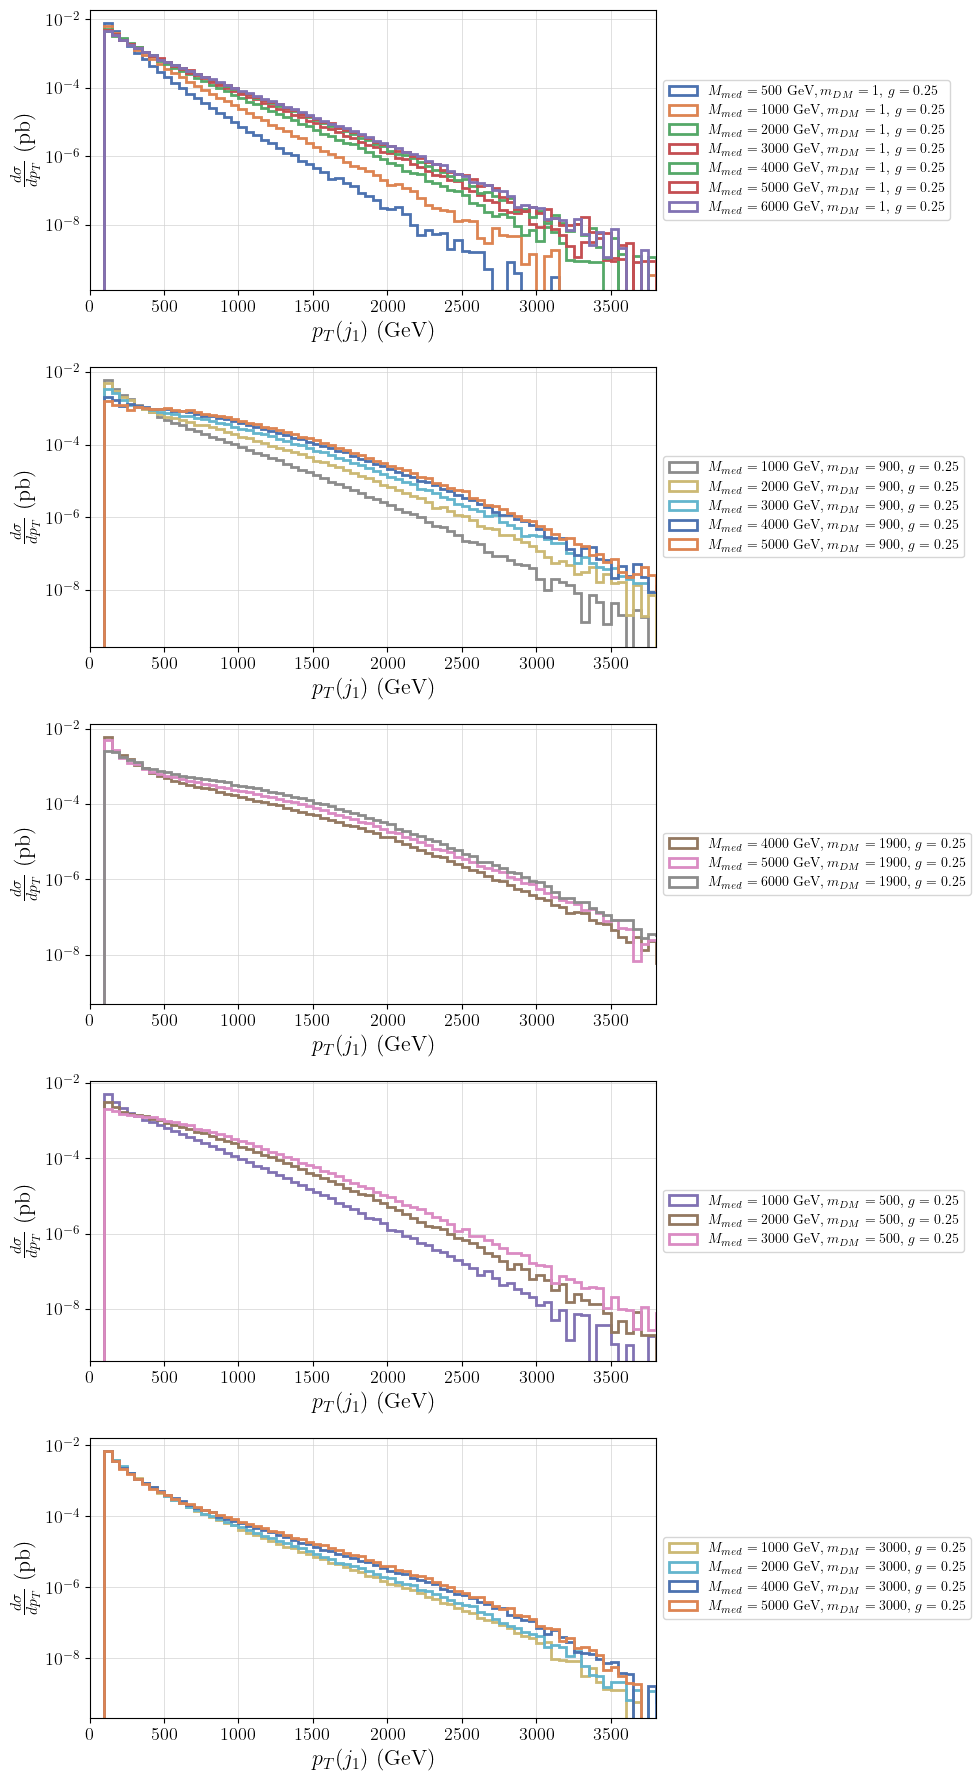

In [22]:
fig, ax = plt.subplots(len(mDM_unique), 1, figsize=(10,18))

for i, mass in enumerate(mDM_unique):
    for label in parameters.keys():
        if parameters[label]['mDM'] != mass: continue
        binc,binEdges,patches = ax[i].hist(pTj1[label],bins=np.linspace(0,5000,101),
                                   label=r'$M_{med} = %1.0f$ GeV$, m_{DM} = %1.0f$, $g = %1.2f$'%(parameters[label]['mMed'], parameters[label]['mDM'], parameters[label]['g']),
                                         histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
#         errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
#         errorc = np.sqrt(errorc2)
#         binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#         ax[i].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
#                      drawstyle = 'steps-mid', color=colors[label])

    
    ax[i].set_yscale('log')
    # plt.ylim(1e-8,5e-5)
    ax[i].set_xlabel(r'$p_T(j_1)$ (GeV)')
    ax[i].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
    ax[i].set_xlim(0,pTj1[label].max()-100)
    ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

plt.show()

In [23]:
parameters

{'run_01': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_02': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_03': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_04': {'mMed': 3000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_05': {'mMed': 1000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_06': {'mMed': 2000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_07': {'mMed': 3000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_08': {'mMed': 1000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_09': {'mMed': 2000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_10': {'mMed': 3000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_11': {'mMed': 4000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_12': {'mMed': 5000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_13': {'mMed': 4000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_14': {'mMed': 5000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_15': {'mMed':

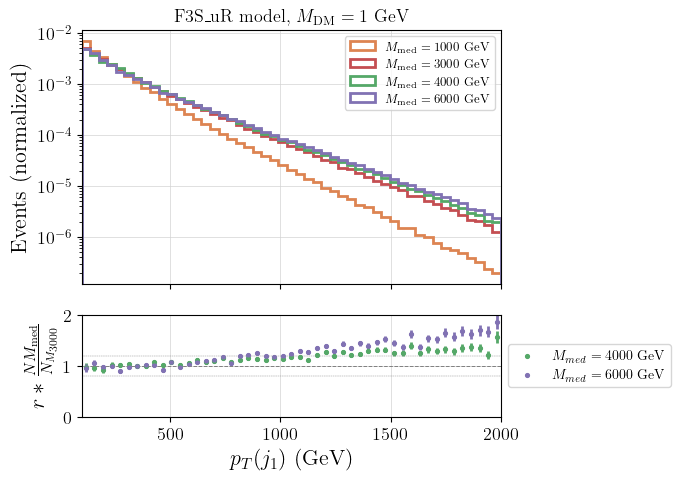

In [79]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 3000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['mDM'] != 1.0: continue
#     if parameters[label]['mDM'] != 950.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != 1.0: continue
#     if parameters[label]['mDM'] == 250.0: continue
    if parameters[label]['mMed'] == 500.0: continue
    if parameters[label]['mMed'] == 2000.0: continue
    if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$M_{\rm med} = %1.0f$ GeV'%(parameters[label]['mMed']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == mass: continue
    if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV'%(parameters[label]['mMed']))
    ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

ax[0].set_title(r'F3S_uR model, $M_{\rm DM} = 1$ GeV')
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(100,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.,2.)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$r * \frac{N{M_{\rm med}}}{N_{M_{3000}}}$')

ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

plt.savefig('./figures/DMsimp_F3S_uR_ptj1_fixed_dm.png')
plt.show()

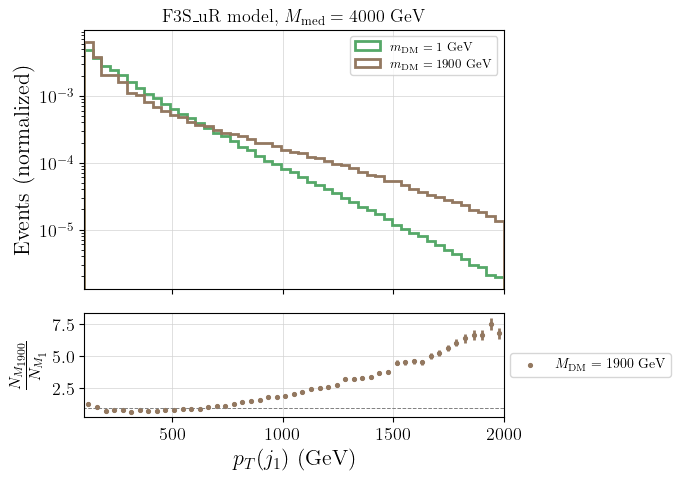

In [80]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 1.0


for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] != 4000.0: continue
#     if parameters[label]['mDM'] != 950.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mMed'] != 4000.0: continue
#     if parameters[label]['mDM'] == 250.0: continue
#     if parameters[label]['mMed'] == 500.0: continue
    if parameters[label]['mDM'] == 900.0: continue
    if parameters[label]['mDM'] == 3000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == mass: continue
#     if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

ax[0].set_title(r'F3S_uR model, $M_{\rm med} = 4000$ GeV')    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(100,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{M_{1900}}}{N_{M_{1}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
# ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
# ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

plt.savefig('./figures/DMsimp_F3S_uR_ptj1_fixed_med.png')
plt.show()

In [39]:
ratioErr

array([2671.49682789, 2748.80210276, 2310.2411722 , 2258.45940746,
       2004.42663427, 2031.23694558, 1947.34024905, 1890.9299318 ,
       1841.92517913, 1738.97361721, 1758.43698568, 1764.60970053,
       1658.05993161, 1690.54877562, 1610.54152854, 1754.6843693 ,
       1599.27422971, 1565.26599551, 1575.21033098, 1670.77358746,
       1577.43845912, 1603.59371202, 1506.10532884, 1451.5401366 ,
       1567.5967956 , 1593.25708864, 1517.830817  , 1459.48179811,
       1544.47445122, 1479.51693266, 1535.30664387, 1508.9602458 ,
       1549.67683995, 1512.2506424 , 1592.47507664, 1534.53013155,
       1548.25085931, 1662.16023039, 1558.44385383, 1518.84199602,
       1638.65224421, 1550.09570894, 1617.91497165, 1683.26446324,
       1742.26353738, 1528.14717722, 1726.11642266, 1681.39212475,
       1807.80094394])

/tmp/ipykernel_160234/2218453863.py:34: RuntimeWarning: divide by zero encountered in divide
  ratiok = k*binc_nodensity/bin_ref_nodensity
/tmp/ipykernel_160234/2218453863.py:35: RuntimeWarning: divide by zero encountered in divide
  ratio = binc/bin_ref
/tmp/ipykernel_160234/2218453863.py:36: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity


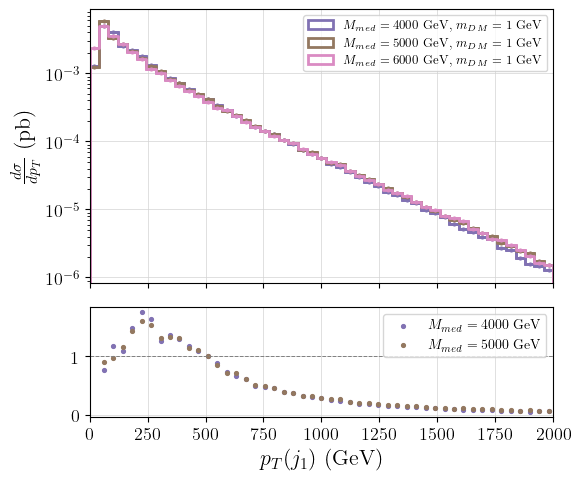

In [34]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 6000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] != 950.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != 1.0: continue
    if parameters[label]['mMed'] == 100.0: continue
#     if parameters[label]['mDM'] == 750.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(0,2000,50),
               label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(0,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == mass: continue
    if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV'%(parameters[label]['mMed']))
#     ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend()
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
 

plt.tight_layout()

# plt.savefig('./figures/ptj1_no_onshell_2000.png')
plt.show()

In [35]:
ratioErr

array([          nan, 1942.66430669, 1164.96893875,  911.53522889,
        859.82369945,  794.39436742,  680.05979977,  507.85479104,
        478.1253189 ,  431.11343476,  366.84717454,  332.97872707,
        289.73075836,  247.18084768,  201.72561594,  191.62337165,
        166.94831378,  140.77366418,  131.99538857,  122.5363681 ,
        106.73145708,  101.96469266,   89.28520657,   88.71089594,
         83.55506157,   76.98103343,   74.79440084,   66.92948809,
         62.71472081,   62.23595016,   58.14501333,   57.58213135,
         54.62735326,   53.87952203,   52.61251877,   49.90223579,
         47.19860292,   46.74188741,   45.39113781,   48.34066073,
         47.39309141,   44.17080374,   47.36028683,   42.32578365,
         44.97038027,   43.22155804,   47.738236  ,   45.13744238,
         46.47127605])

In [27]:
ratio

array([0.3988655 , 0.61051078, 1.37020308, 1.44173539, 1.77938197,
       2.17479342, 2.05058122, 2.28163065, 2.38041081, 2.09922286,
       2.33632547, 2.28913579, 2.07007102, 1.85873591, 1.96278663,
       1.68296403, 1.51519643, 1.38734583, 1.36316226, 1.25320437,
       1.15859814, 1.12636546, 1.06377957, 0.98740764, 0.89082068,
       0.8934899 , 0.84690524, 0.76555041, 0.73407093, 0.68654281,
       0.65385944, 0.59091276, 0.59141578, 0.57132922, 0.53649719,
       0.48795477, 0.48877887, 0.44664033, 0.43747871, 0.45526529,
       0.36855446, 0.36592445, 0.3377171 , 0.3737621 , 0.34896487,
       0.31630813, 0.30155401, 0.25656809, 0.30309816])

In [28]:
ratiok

array([0.399315  , 0.61119879, 1.37174723, 1.44336017, 1.78138726,
       2.17724432, 2.05289213, 2.28420195, 2.38309343, 2.10158859,
       2.3389584 , 2.29171554, 2.0724039 , 1.86083062, 1.96499861,
       1.68486066, 1.51690399, 1.38890931, 1.36469848, 1.25461668,
       1.15990383, 1.12763482, 1.06497841, 0.9885204 , 0.8918246 ,
       0.89449683, 0.84785966, 0.76641315, 0.7348982 , 0.68731652,
       0.65459631, 0.59157869, 0.59208228, 0.57197308, 0.5371018 ,
       0.48850468, 0.4893297 , 0.44714368, 0.43797173, 0.45577836,
       0.36896981, 0.36633683, 0.33809769, 0.37418331, 0.34935814,
       0.3166646 , 0.30189385, 0.25685723, 0.30343974])

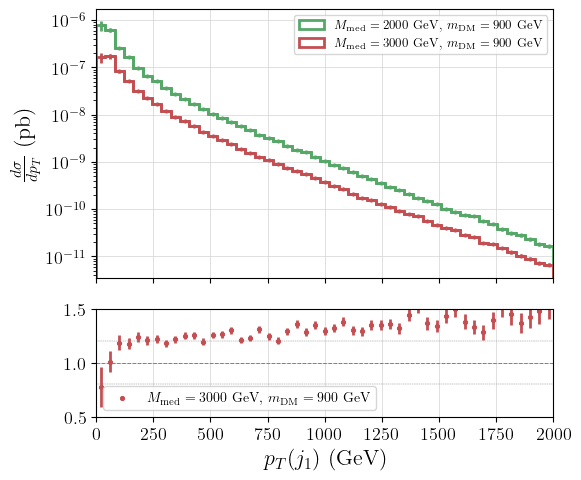

In [68]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 2000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] != 950.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != 900.0: continue
    if parameters[label]['mMed'] == 100.0: continue
#     if parameters[label]['mDM'] == 750.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,2000,50),
                                   label=r'$M_{\rm med} = %1.0f$ GeV, $m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == mass: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{\rm med} = %1.0f$ GeV, $m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.5,1.5)
ax[1].legend()
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

plt.tight_layout()

# plt.savefig('./figures/ptj1_no_onshell_2000.png')
plt.show()

In [38]:
parameters

{'run_01': {'mMed': 100.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_02': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_03': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_04': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_05': {'mMed': 3000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_06': {'mMed': 500.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_07': {'mMed': 1000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_08': {'mMed': 2000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_09': {'mMed': 3000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_10': {'mMed': 1000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_11': {'mMed': 2000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_12': {'mMed': 3000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_13': {'mMed': 2000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_14': {'mMed': 3000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000}}

In [37]:
totalweight

{'run_01': 0.22904674392047525,
 'run_02': 0.004317065723305439,
 'run_03': 0.0005019782879924701,
 'run_04': 5.563833003870651e-05,
 'run_05': 1.1196911350640074e-05,
 'run_06': 0.0013545486102423164,
 'run_07': 0.00020507032508049655,
 'run_08': 2.9248238067221442e-05,
 'run_09': 7.236047598802706e-06,
 'run_10': 9.51188381103729e-05,
 'run_11': 1.316332225297084e-05,
 'run_12': 3.9677676875246816e-06,
 'run_13': 2.2050420662778916e-06,
 'run_14': 5.973365402504444e-07}

/tmp/ipykernel_11918/1857687031.py:34: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_11918/1857687031.py:34: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_11918/1857687031.py:35: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs


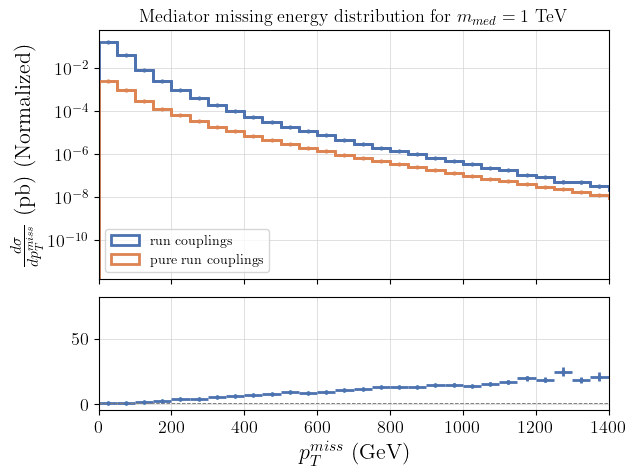

In [50]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(6,5))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

# k=1
# k = totalweight['pseudoscalar_run03']/totalweight['scalar_run03']
k = totalweight['run_01']/totalweight['run_02']

for label,metPts in met.items():
    if label in ['run_02']:
        bincSc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'pure %s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)
        errorSc[errorSc<0] = 0
        ax[0].errorbar(binCenter,bincSc,yerr = errorSc, marker = '.', drawstyle = 'steps-mid',color=colors[label])

    
    if label in ['run_01']:
        bincPs,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorPs = np.sqrt(errorPs2)
        errorPs[errorPs<0] = 0
        
        ax[0].errorbar(binCenter,bincPs,yerr = errorPs, marker = '.', drawstyle = 'steps-mid',color=colors[label])

        
ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio, xerr = errorh, yerr = ratioErr, fmt='.', color=colors['run_01'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
# ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
# ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

        
ax[0].set_yscale('log')
# ax[0].set_ylim(6e-8,2e-2)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(0,1400)
ax[0].legend(loc='lower left')
ax[0].set_title(r'Mediator missing energy distribution for $m_{med} = 1$ TeV')


# ax[1].set_ylim(0.5,1.5)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')

# plt.savefig('plot-s-ps-bias.png')
plt.show()

In [42]:
len(binCenter)

49

In [45]:
len(bincPs)

100

In [115]:
parameters

{'run_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_03': {'mMed': 1000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_04': {'mMed': 1000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_05': {'mMed': 2500.0, 'mDM': 600.0, 'g': 0.25, 'Events': 50000},
 'run_06': {'mMed': 2500.0, 'mDM': 1200.0, 'g': 0.25, 'Events': 50000},
 'run_07': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_08': {'mMed': 500.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_09': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_10': {'mMed': 2000.0, 'mDM': 250.0, 'g': 0.25, 'Events': 50000},
 'run_11': {'mMed': 2000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_12': {'mMed': 2000.0, 'mDM': 750.0, 'g': 0.25, 'Events': 50000},
 'run_13': {'mMed': 2000.0, 'mDM': 950.0, 'g': 0.25, 'Events': 50000},
 'run_14': {'mMed': 250.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_15': {'mMed'

/tmp/ipykernel_45894/2886357679.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/2886357679.py:31: RuntimeWarning: invalid value encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/2886357679.py:32: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref


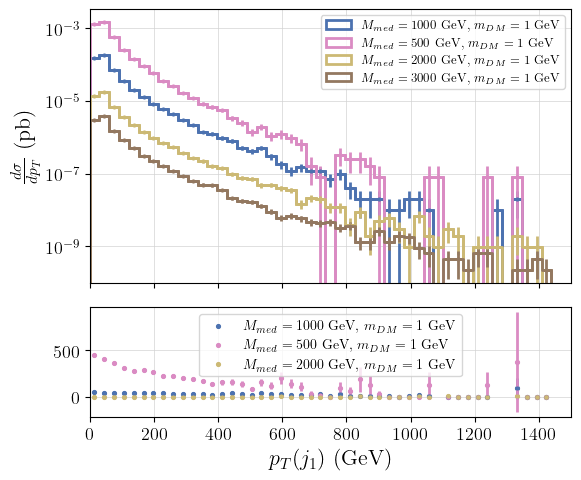

In [124]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 1


for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] != 3000.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] == 250.0: continue
    if parameters[label]['mMed'] == 2500.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,1500,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == 3000.0: continue
#     k = weight_ref/totalweight[label]
    k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend()
 

plt.tight_layout()

plt.savefig('./figures/ptj1_no_onshell_mxd_1.png')
plt.show()

/tmp/ipykernel_45894/1945078493.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/1945078493.py:32: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref


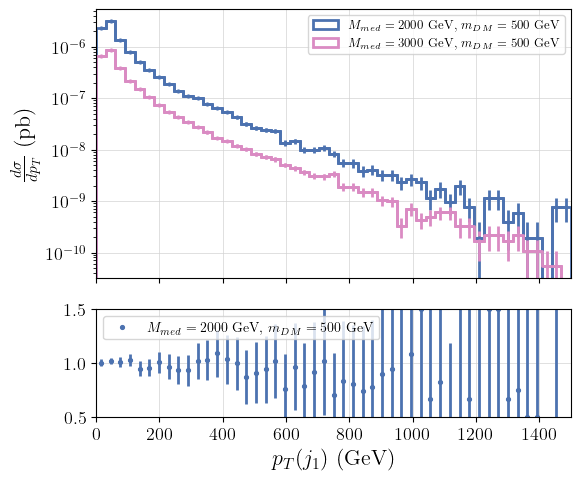

In [127]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 500


for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] != 3000.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
#     if parameters[label]['mMed'] == 250.0: continue
#     if parameters[label]['mMed'] == 2500.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,1500,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == 3000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.5,1.5)
ax[1].legend()
 

plt.tight_layout()

plt.savefig('./figures/ptj1_no_onshell_mxd_500.png')
plt.show()

/tmp/ipykernel_45894/687533758.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/687533758.py:31: RuntimeWarning: invalid value encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/687533758.py:32: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref


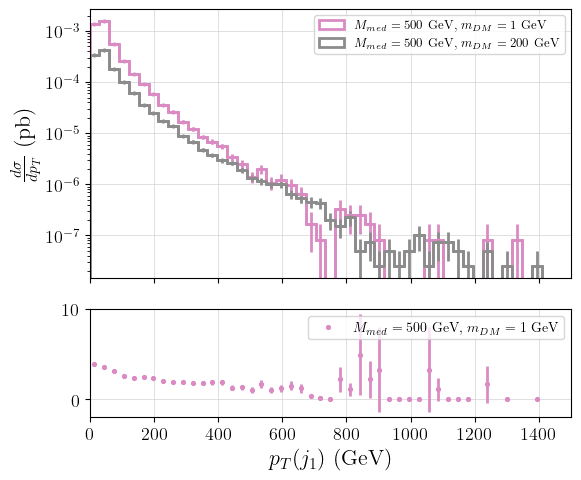

In [121]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 500


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['mDM'] != 200.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['mDM'] == 250.0: continue
    if parameters[label]['mDM'] == 750.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,1500,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == 200.0: continue
#     k = weight_ref/totalweight[label]
    k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend()
 

plt.tight_layout()

plt.savefig('./figures/ptj1_no_onshell_500.png')
plt.show()

In [92]:
pt_ref

array([4.36293696e-07, 5.90510571e-07, 2.68378916e-07, 1.62258622e-07,
       1.06312680e-07, 7.11059839e-08, 5.57920328e-08, 4.23634677e-08,
       3.31674016e-08, 2.40482900e-08, 2.06622908e-08, 1.75456324e-08,
       1.42750649e-08, 1.07351567e-08, 9.96561138e-09, 8.81129346e-09,
       7.15677110e-09, 6.38722582e-09, 5.30986243e-09, 4.50183989e-09,
       3.42447650e-09, 3.46295376e-09, 2.65493122e-09, 2.69340848e-09,
       1.80843141e-09, 1.88538594e-09, 1.65452235e-09, 1.65452235e-09,
       9.23454336e-10, 1.11584066e-09, 8.46499808e-10, 6.15636224e-10,
       7.31068016e-10, 6.54113488e-10, 5.00204432e-10, 4.61727168e-10,
       2.30863584e-10, 4.23249904e-10, 3.07818112e-10, 2.30863584e-10,
       2.30863584e-10, 1.53909056e-10, 2.30863584e-10, 2.30863584e-10,
       7.69545280e-11, 3.84772640e-11, 2.30863584e-10, 7.69545280e-11,
       7.69545280e-11])

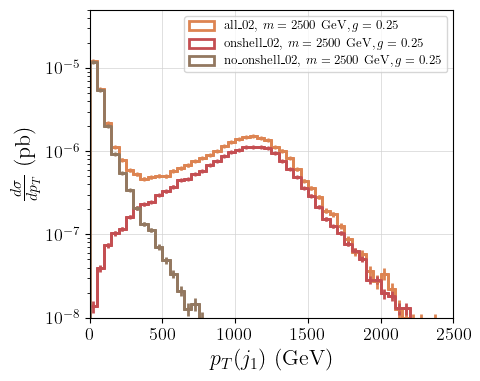

In [36]:
fig = plt.figure()
for label,pt in pTj1.items():
    if '01' in label: continue
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.0f$ GeV$, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], weights=weights[label],linewidth=2, density=False)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2500)
plt.legend(loc='upper right', fontsize='x-small')
plt.tight_layout()

plt.savefig('ptj_02.png')
plt.show()

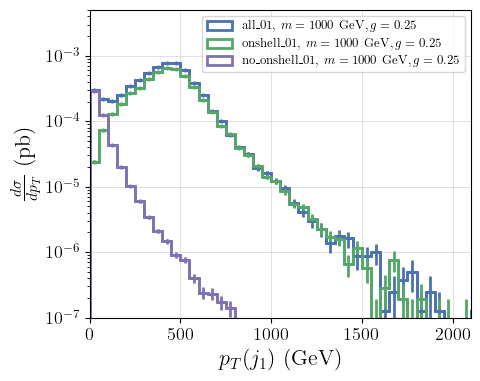

In [35]:
fig = plt.figure()
for label,pt in pTj1.items():
    if '02' in label: continue
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.0f$ GeV$, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], weights=weights[label],linewidth=2, density=False)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
plt.ylim(1e-7,5e-3)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2100)
plt.legend(loc='upper right', fontsize='x-small')
plt.tight_layout()

plt.savefig('ptj_01.png')
plt.show()

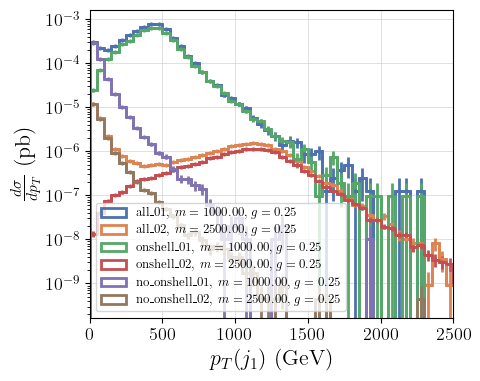

In [20]:
fig = plt.figure()
for label,pt in pTj1.items():
#     if label in ['scalar_run03']:
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.0f$ GeV$, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], weights=weights[label],linewidth=2, density=False)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
# plt.ylim(1e-9,1e-3)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2500)
plt.legend(loc='lower left', fontsize='x-small')
plt.tight_layout()

plt.show()

In [16]:
parameters

{'all_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'all_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'onshell_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'onshell_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'no_onshell_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'no_onshell_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000}}

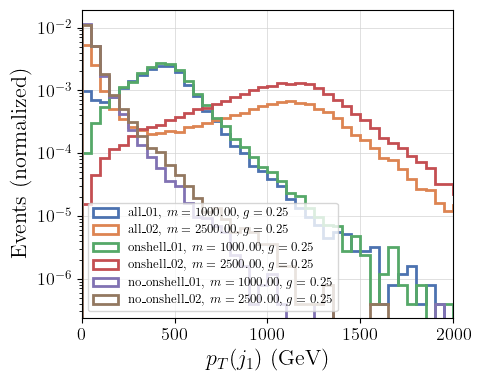

In [17]:
fig = plt.figure()
for label,pt in pTj1.items():
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.2f, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], linewidth=2, density=True)

    
plt.yscale('log')
# plt.ylim(1e-9,1e-3)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'Events (normalized)')
plt.xlim(0,2000)
plt.legend(loc='lower left', fontsize='x-small')
plt.tight_layout()
# plt.savefig('./figs_tchannel/plot_PTj_normalized_v2.png')

plt.show()

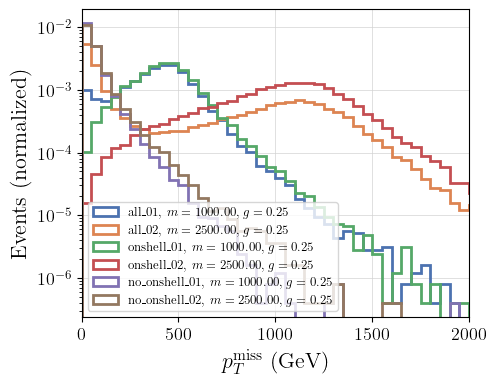

In [18]:
fig = plt.figure()
for label,pt in met.items():
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.2f, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),histtype='step',color=colors[label],
                               linewidth=2, density=True)
#     errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
#     errorc = np.sqrt(errorc2)
#     binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
#                  drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
# plt.ylim(1e-9,1e-3)
plt.xlabel(r'$p_T^{\rm miss}$ (GeV)')
plt.ylabel(r'Events (normalized)')
plt.xlim(0,2000)
plt.legend(loc='lower left', fontsize='x-small')
plt.tight_layout

plt.show()

In [14]:
# fig = plt.figure(figsize=(10,6))
# for label,metPts in met.items():
#     if 'run01' in label:
#         binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
#                                         label=r'%s; $m_{DM} $= %1.f GeV' %(label.split('_')[0], parameters[label]['mDM']),
#                                          histtype='step',color=colors[label],
#                                          weights=weights[label],linewidth=2, density=True)
#         errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
#         errorc = np.sqrt(errorc2)
#         binCenter = (binEdges[0:-1]+binEdges[1:])/2.
# #         plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
# #                      drawstyle = 'steps-mid',color=colors[label])
#     if 'run02' in label:
#         binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
#                                          label=r'%s; $m_{DM} $= %1.f GeV' %(label.split('_')[0], parameters[label]['mDM']),
#                                          histtype='step',color=colors[label],
#                                          weights=weights[label],linewidth=2, density=True)
#         errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
#         errorc = np.sqrt(errorc2)
#         binCenter = (binEdges[0:-1]+binEdges[1:])/2.

    
# plt.yscale('log')
# # plt.ylim(1e-8,1)
# plt.xlabel(r'$p_T^{miss}$ (GeV)')
# plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
# plt.xlim(0,1500)
# plt.legend(loc='lower left', fontsize='xx-small')
# plt.title(r'Missing energy distribution for $m_{med} = 500$ GeV')
# plt.show()

In [15]:
# fig = plt.figure(figsize=(10,6))
# for label,metPts in met.items():
#     if 'run04' in label:
#         binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
#                                    label=label,histtype='step',color=colors[label],
#                                    weights=weights[label],linewidth=2,density=True)
# #         errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
# #         errorc = np.sqrt(errorc2)
# #         binCenter = (binEdges[0:-1]+binEdges[1:])/2.
# #         plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
# #                      drawstyle = 'steps-mid',color=colors[label])

    
# plt.yscale('log')
# # plt.ylim(1e-3,1)
# plt.xlabel(r'$p_T^{miss}$ (GeV)')
# plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
# plt.xlim(0,2000)
# plt.legend(loc='upper right', fontsize='x-small')
# plt.show()

/tmp/ipykernel_66296/3762056230.py:32: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3762056230.py:32: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3762056230.py:33: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs


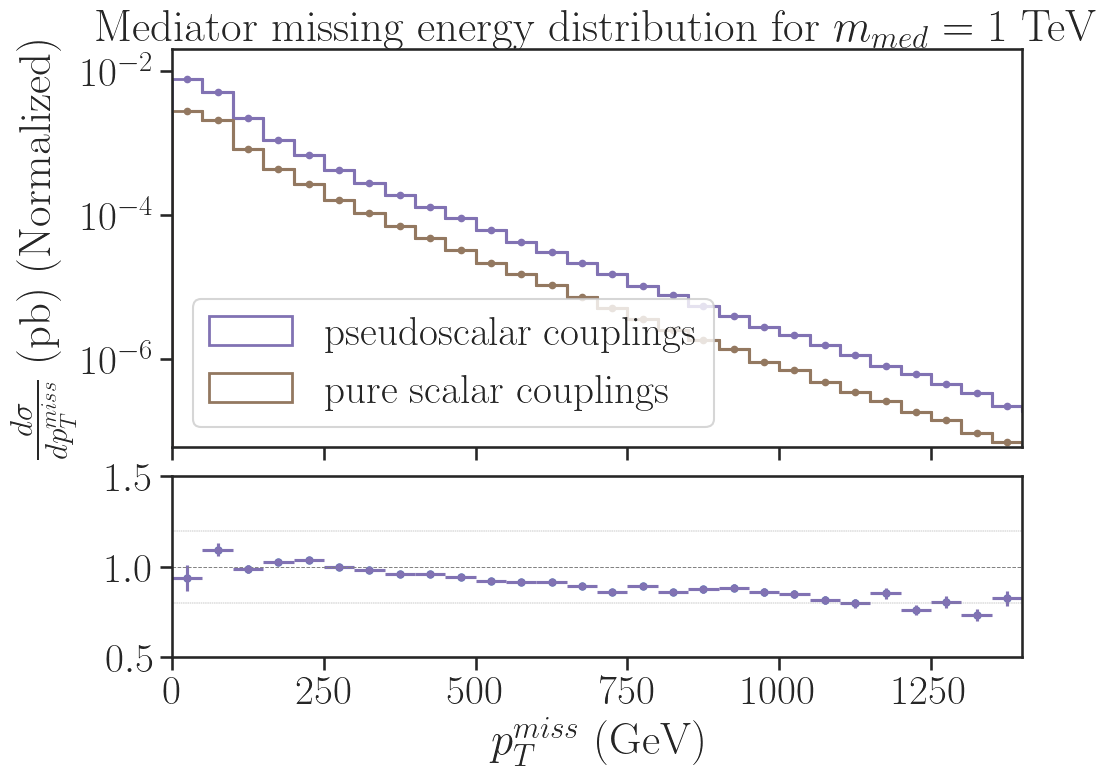

In [16]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

# k=1
k = totalweight['pseudoscalar_run03']/totalweight['scalar_run03']

for label,metPts in met.items():
    if label in ['scalar_run03']:
        bincSc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'pure %s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)
        errorSc[errorSc<0] = 0
        ax[0].errorbar(binCenter,bincSc,yerr = errorSc, marker = '.', drawstyle = 'steps-mid',color=colors[label])

    
    if label in ['pseudoscalar_run03']:
        bincPs,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorPs = np.sqrt(errorPs2)
        errorPs[errorPs<0] = 0
        
        ax[0].errorbar(binCenter,bincPs,yerr = errorPs, marker = '.', drawstyle = 'steps-mid',color=colors[label])

        
ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio,xerr = errorh, yerr = ratioErr, fmt='.', color=colors['pseudoscalar_run03'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

        
ax[0].set_yscale('log')
ax[0].set_ylim(6e-8,2e-2)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(0,1400)
ax[0].legend(loc='lower left')
ax[0].set_title(r'Mediator missing energy distribution for $m_{med} = 1$ TeV')


ax[1].set_ylim(0.5,1.5)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')

# plt.savefig('plot-s-ps-bias.png')
plt.show()

/tmp/ipykernel_66296/3705865879.py:28: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3705865879.py:28: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3705865879.py:29: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


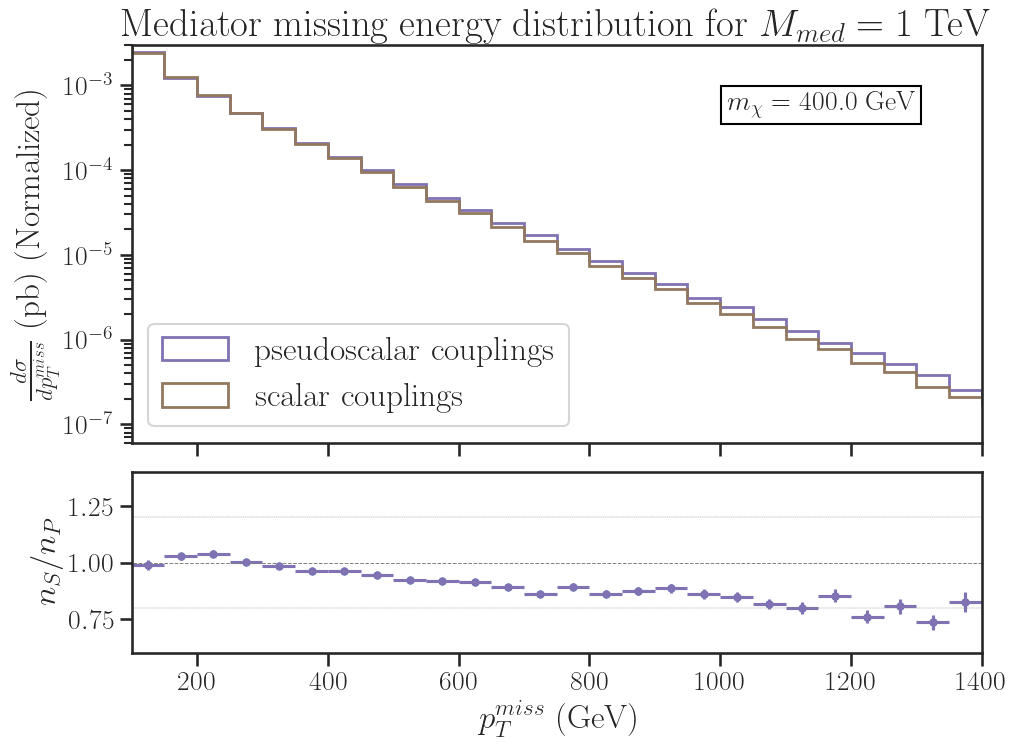

In [17]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['pseudoscalar_run03']/totalweight['scalar_run03']

for label,metPts in met.items():
    if label in ['scalar_run03']:
        bincScNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincSc, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)

    
    if label in ['pseudoscalar_run03']:
        bincPsNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincPs, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorPs = np.sqrt(errorPs2)

        

ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio,xerr = errorh, yerr = ratioErr, fmt='.', color=colors['pseudoscalar_run03'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

        
ax[0].set_yscale('log')
ax[0].set_ylim(6e-8,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)', fontsize=24)
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=24)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV', fontsize=28)

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run03']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params(labelsize=20)
ax[1].tick_params(labelsize=20)


ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)', fontsize=24)
ax[1].set_ylabel(r'$n_{S}/n_{P}$', fontsize=24)


plt.savefig('plot-s-ps-bias-mdm400.eps', format='eps')
plt.show()

/tmp/ipykernel_66296/1482585364.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/1482585364.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/1482585364.py:28: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs


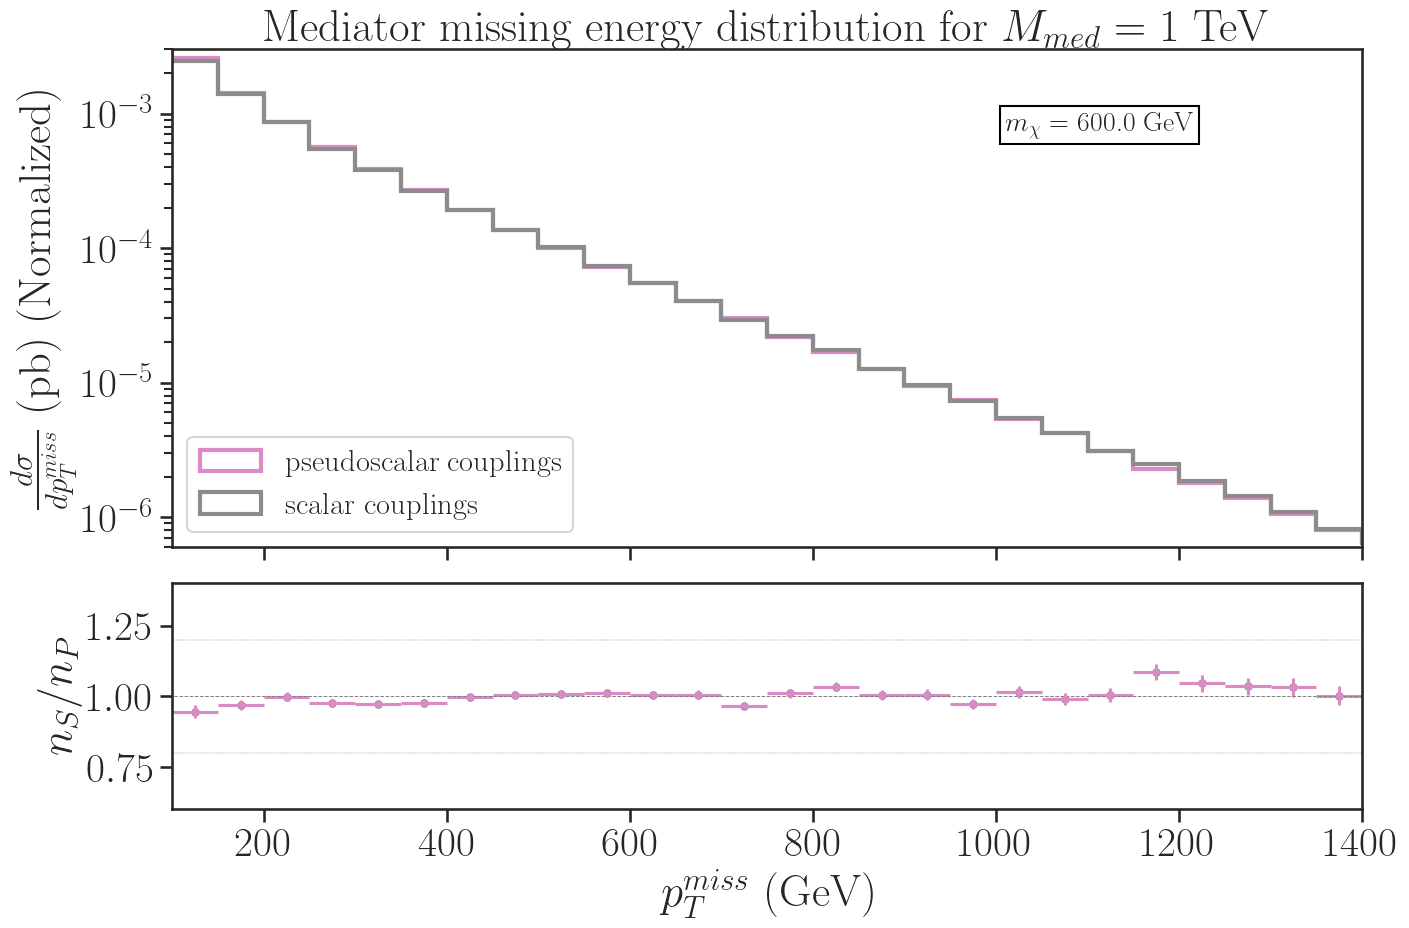

In [36]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(14,10))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['pseudoscalar_run04']/totalweight['scalar_run04']

for label,metPts in met.items():
    if label in ['scalar_run04']:
        bincScNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        bincSc, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)

    
    if label in ['pseudoscalar_run04']:
        bincPsNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        bincPs, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorPs = np.sqrt(errorPs2)

        
ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio,xerr=errorh, yerr=ratioErr, fmt='.', color=colors['pseudoscalar_run04'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)


ax[0].set_yscale('log')
ax[0].set_ylim(6e-7,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=22)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV')

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run04']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params()
ax[1].tick_params()


ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')
ax[1].set_ylabel(r'$n_{S}/n_{P}$')


plt.savefig('plot-s-ps-bias-mdm600.png', dpi=600)
plt.show()

/tmp/ipykernel_66296/2192451492.py:28: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/2192451492.py:28: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/2192451492.py:29: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec


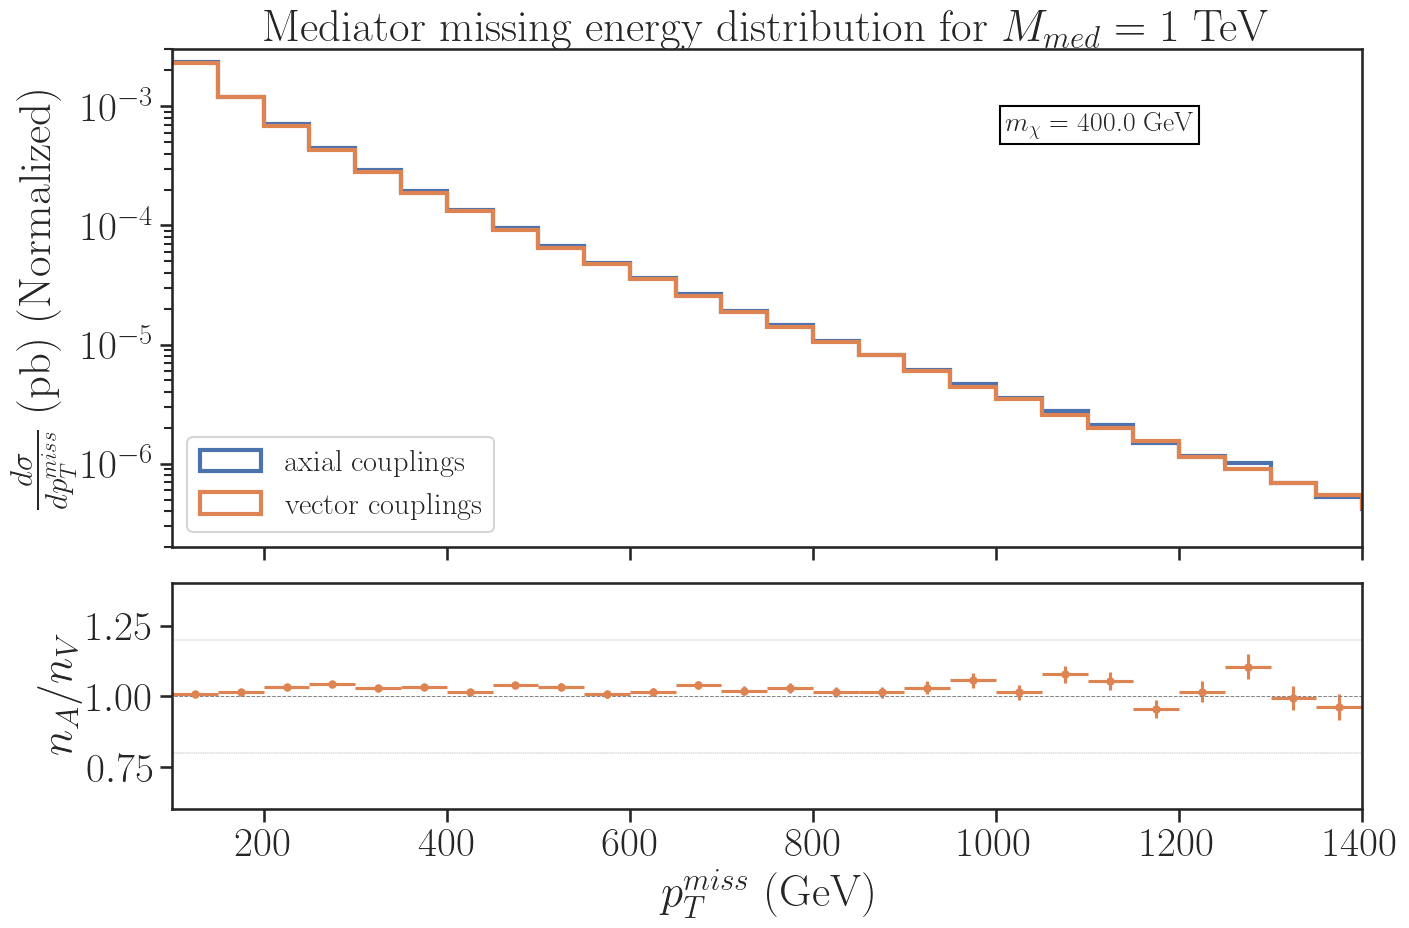

In [34]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(14,10))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['vector_run03']/totalweight['axial_run03']

for label,metPts in met.items():
    if label in ['axial_run03']:
        bincAxNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        
        bincAx, _ = np.histogram(metPts,bins=binEdges,weights=weights[label], density=False)
        errorAx2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2, density=False)
        errorAx = np.sqrt(errorAx2)
        
    elif label in ['vector_run03']:
        bincVecNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        
        bincVec, _ = np.histogram(metPts,bins=binEdges,weights=weights[label], density=False)
        errorVec2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2, density=False)
        errorVec = np.sqrt(errorVec2)
        
        
ratio = k*bincAx/bincVec
ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec

binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()    

ax[1].scatter(binCenter, ratio, marker='.', color=colors['vector_run03'])
ax[1].errorbar(binCenter,ratio, xerr = errorh, yerr=ratioErr, fmt='.', color=colors['vector_run03'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
        

ax[0].set_yscale('log')
ax[0].set_ylim(2e-7,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=22)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV')

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['axial_run03']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params()
ax[1].tick_params()

ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')
ax[1].set_ylabel(r'$n_{A}/n_{V}$')

plt.savefig('plot-v-av-mxd400.png', dpi=600)
plt.show()

/tmp/ipykernel_66296/4252788444.py:28: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/4252788444.py:28: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/4252788444.py:29: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


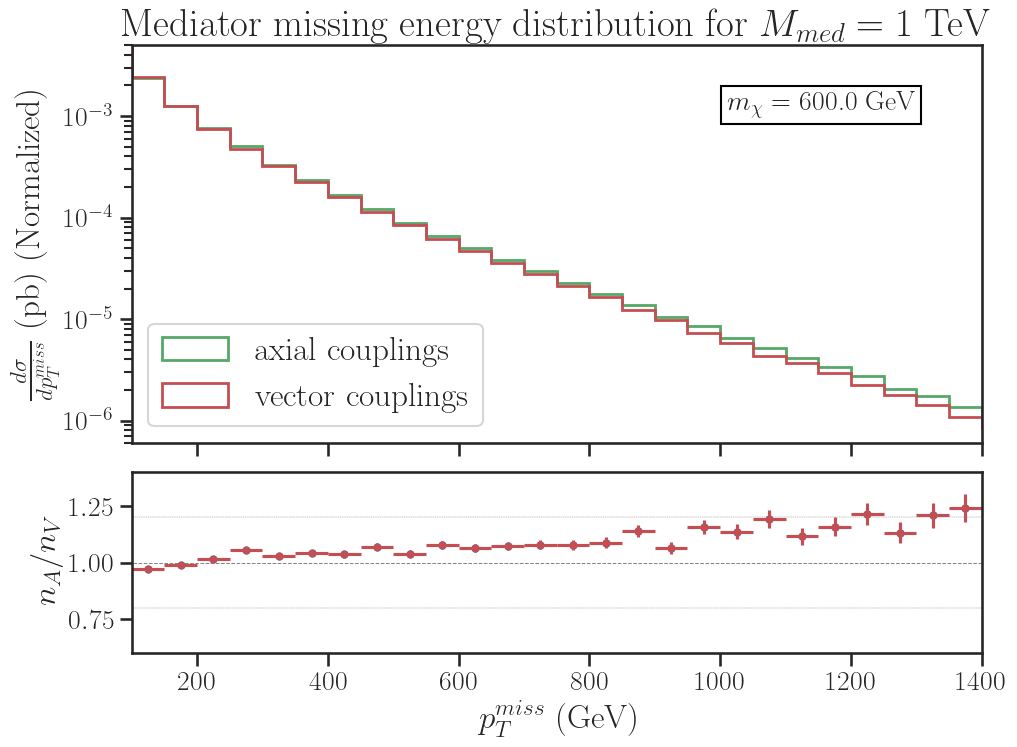

In [20]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['vector_run04']/totalweight['axial_run04']


for label,metPts in met.items():
    if label in ['axial_run04']:
        bincAxNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincAx, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorAx2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorAx = np.sqrt(errorAx2)
        
    elif label in ['vector_run04']:
        bincVecNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincVec, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorVec2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorVec = np.sqrt(errorVec2)
    
        
        
ratio = k*bincAx/bincVec
ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()    

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio, xerr = errorh, yerr=ratioErr, fmt='.', color=colors['vector_run04'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
        

ax[0].set_yscale('log')
ax[0].set_ylim(6e-7,5e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)', fontsize=24)
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=24)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV', fontsize=28)

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['axial_run04']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params(labelsize=20)
ax[1].tick_params(labelsize=20)

ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)', fontsize=24)
ax[1].set_ylabel(r'$n_{A}/n_{V}$', fontsize=24)


plt.savefig('plot-v-av-mxd600.eps', format='eps')
plt.show()

/tmp/ipykernel_66296/2434960696.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2434960696.py:23: RuntimeWarning: invalid value encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2434960696.py:24: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


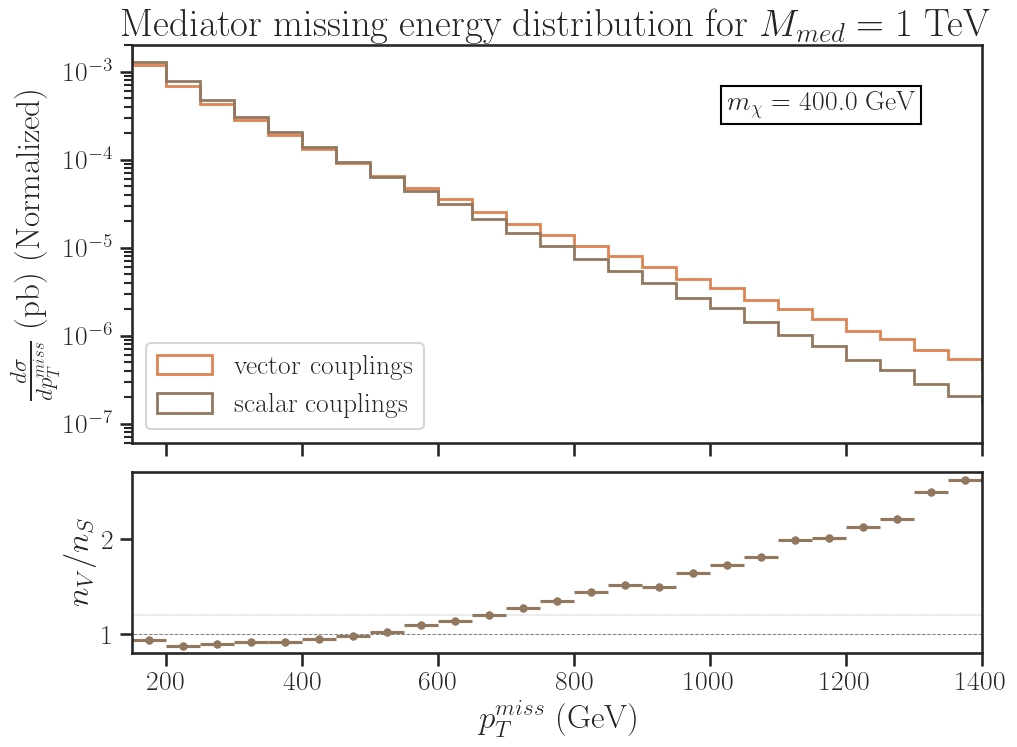

In [21]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

for label,metPts in met.items():
    if label in ['vector_run03']:
        bincS1,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        errorS1, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        
for label,metPts in met.items():
    if label in ['scalar_run03']:
        binc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorh = (np.diff(binEdges+[2000.])/2).tolist()
        errorL, _ =  np.histogram(metPts,bins=binEdges,weights=weights[label]**2) 
        
        ratio = bincS1/binc
        ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc

        ax[1].scatter(binCenter, ratio, marker='.', label=r'%s couplings' %(label.split('_')[0]),
                      color=colors[label])
        ax[1].errorbar(binCenter,ratio, xerr=errorh, yerr=ratioErr, fmt='.', color=colors[label])
        
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
  
ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run03']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)
ax[0].set_yscale('log')
ax[0].set_ylim(6e-8,2e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)', fontsize=24)
ax[0].set_xlim(150,1400)
ax[0].legend(loc='lower left', fontsize=20)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV', fontsize=28)
ax[0].tick_params(labelsize=20)


ax[1].tick_params(labelsize=20)
ax[1].set_ylim(0.8,2.7)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)', fontsize=24)
ax[1].set_ylabel(r'$n_{V}/n_{S}$', fontsize=24)

plt.savefig('plot-s-ps-v-av-mxd400.eps', format='eps')
plt.show()

/tmp/ipykernel_66296/2430933865.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2430933865.py:23: RuntimeWarning: invalid value encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2430933865.py:24: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc


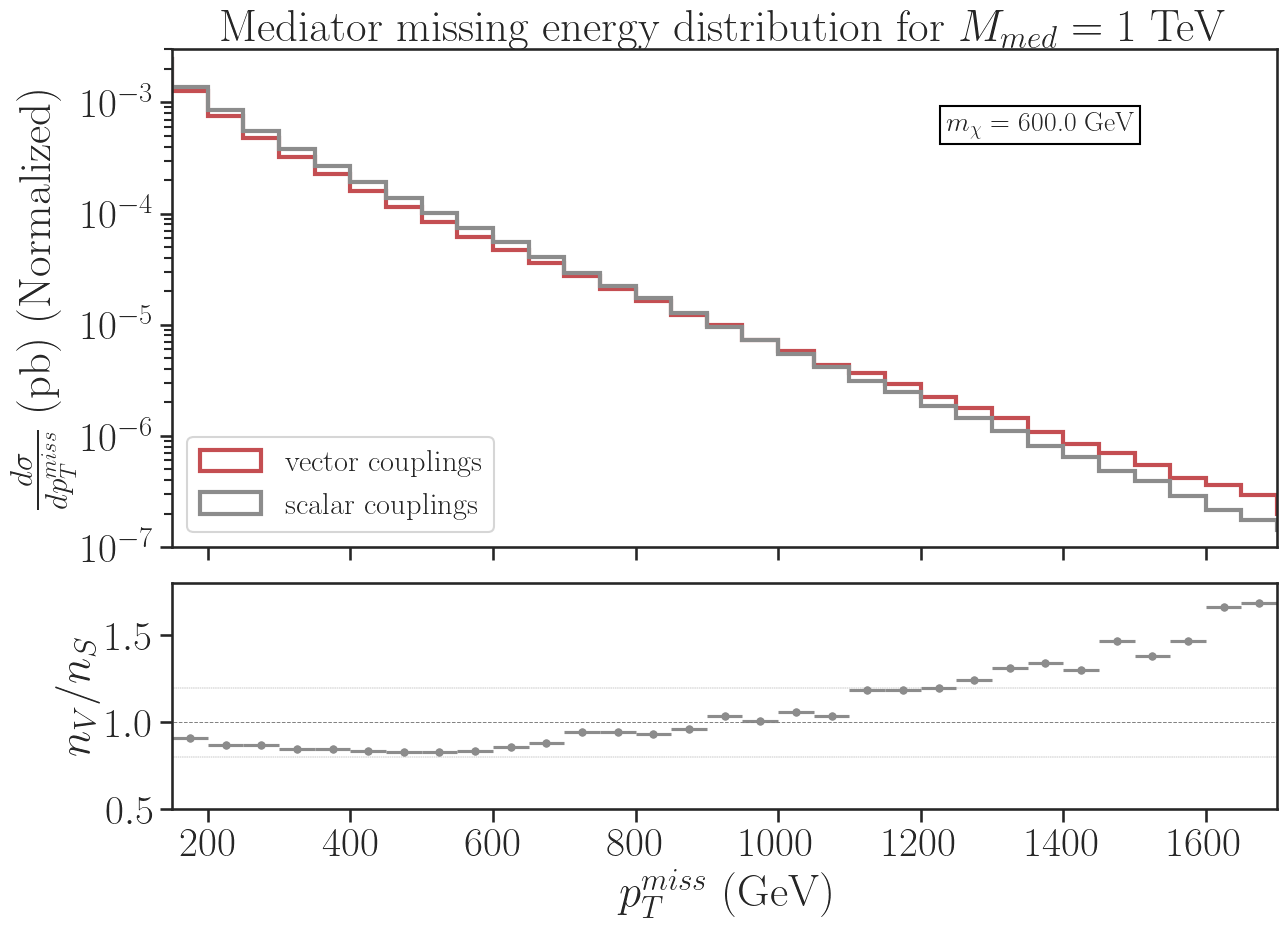

In [32]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(13,10))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

for label,metPts in met.items():
    if label in ['vector_run04']:
        bincS1,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        errorS1, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        
for label,metPts in met.items():
    if label in ['scalar_run04']:
        k = totalweight['vector_run04']/totalweight[label]
        binc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorh = (np.diff(binEdges+[2000.])/2).tolist()
        errorL, _ =  np.histogram(metPts,bins=binEdges,weights=weights[label]**2) 
        
        ratio = bincS1/binc
        ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc


        ax[1].scatter(binCenter, ratio, marker='.', label=r'%s couplings' %(label.split('_')[0]),
                      color=colors[label])
        ax[1].errorbar(binCenter,ratio, xerr=errorh, yerr = ratioErr, fmt='.', color=colors[label])

        
    
        
ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run04']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
    
ax[0].set_yscale('log')
ax[0].set_ylim(1e-7,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(150,1700)
ax[0].legend(loc='lower left', fontsize=22)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV')
ax[0].tick_params()


ax[1].tick_params()
ax[1].set_ylim(0.5,1.8)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')
ax[1].set_ylabel(r'$n_{V}/n_{S}$')

plt.savefig('plot-s-ps-v-av-mxd600.png', dpi=600)
plt.show()

In [23]:
ratioErr

array([2.75031171e-05, 6.18180728e-06, 1.93274017e-06, 8.68645885e-07,
       4.95844049e-07, 3.27708967e-07, 2.27724688e-07, 1.69658040e-07,
       1.30544544e-07, 1.03147759e-07, 8.46770934e-08, 7.10531165e-08,
       6.16712741e-08, 5.42753233e-08, 5.02493418e-08, 4.41335534e-08,
       3.85199882e-08, 3.51750676e-08, 3.38878753e-08, 2.95943046e-08,
       2.81988394e-08, 2.51052917e-08, 2.62150654e-08, 2.39386362e-08,
       2.23642630e-08, 2.13840125e-08, 2.09629354e-08, 1.98039259e-08,
       1.78706822e-08, 1.88183626e-08, 1.66440708e-08, 1.64828066e-08,
       1.76279353e-08, 1.68168720e-08, 1.32200798e-08, 1.60411681e-08,
       1.41908551e-08, 1.38921760e-08, 1.25068607e-08, 1.37231823e-08,
       1.11534951e-08, 1.20713292e-08, 1.02771378e-08, 1.82055352e-08,
       7.83635578e-09, 7.24586807e-09, 1.13214288e-08, 1.43201630e-08,
       1.36966192e-08, 9.37134401e-09, 5.67803146e-09, 5.09716825e-09,
       1.86489380e-08, 9.13969747e-09, 2.12114808e-08, 2.22895904e-09,
      

In [24]:

# inputFiles = {'axial_nnlo_01': '../DMSimp_axial_parton/Events/run_17/unweighted_events.lhe.gz',
#               'axial_lo_01': '../DMSimp_axial_parton/Events/run_16/unweighted_events.lhe.gz',
#               'axial_lo_02': '../DMSimp_axial_parton/Events/run_15/unweighted_events.lhe.gz',
#               'axial_nnlo_02': '../DMSimp_axial_parton/Events/run_14/unweighted_events.lhe.gz',
#               'axial_nnlo_03': 